In [28]:
import os
import numpy as np
import librosa

# Define path
DATASET_PATH = os.path.join('..', 'DATASET') # Adjust if your path is different

# 1. Feature Extraction (Keep the time dimension!)
def extract_features_sequence(file_path, max_pad_len=44):
    try:
        audio, sample_rate = librosa.load(file_path, sr=16000)
        audio, _ = librosa.effects.trim(audio)
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
        
        # Padding/Truncating: Neural networks need fixed input sizes.
        if mfccs.shape[1] > max_pad_len:
            mfccs = mfccs[:, :max_pad_len]
        else:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
            
        return mfccs.T  # Transpose to get shape (Time, Features)
    except Exception as e:
        print(f"Error: {e}")
        return None

# 2. Load Data into 'features' and 'y'
features = []
y = []

if not os.path.exists(DATASET_PATH):
    print(f"Error: Dataset path '{DATASET_PATH}' not found.")
else:
    print("Loading data for LSTM...")
    for speaker in os.listdir(DATASET_PATH):
        speaker_path = os.path.join(DATASET_PATH, speaker)
        if os.path.isdir(speaker_path):
            for digit in os.listdir(speaker_path):
                digit_path = os.path.join(speaker_path, digit)
                if os.path.isdir(digit_path):
                    for audio_file in os.listdir(digit_path):
                        if audio_file.endswith('.wav'):
                            file_path = os.path.join(digit_path, audio_file)
                            
                            # Extract using the SEQUENCE function
                            data = extract_features_sequence(file_path)
                            
                            if data is not None:
                                features.append(data)
                                y.append(int(digit))
    print(f"Loaded {len(features)} files.")

Loading data for LSTM...
Loaded 1594 files.


In [33]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

# 3. Reshape for LSTM: (Samples, Time Steps, Features)
# Convert lists to numpy arrays --> X shape should be approx (1500, 44, 13)
X = np.array(features) 

# One-hot encode labels (0 -> [1,0,0...])
y_onehot = to_categorical(y, num_classes=10) 

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 4. Build LSTM Model (Updated for Keras 3+)
model = Sequential()
model.add(Input(shape=(44, 13)))
model.add(LSTM(256, return_sequences=False))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 5. Train
print("Starting Training...")
model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)
print("Training Complete.")

Starting Training...
Training Complete.


In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Predict on the Test Set
# The model outputs probabilities (e.g., [0.1, 0.8, 0.1]), not the digit itself
y_pred_probs = model.predict(X_test)

# 2. Convert Probabilities to Class Labels (Integers)
# np.argmax finds the index of the highest probability
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 3. Calculate Accuracy
acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ LSTM Model Accuracy: {acc * 100:.2f}%")

# 4. Detailed Classification Report
print("--- Classification Report ---")
print(classification_report(y_true_classes, y_pred_classes))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

✅ LSTM Model Accuracy: 92.48%
--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        28
           1       0.79      1.00      0.88        34
           2       0.86      0.94      0.90        32
           3       0.94      0.92      0.93        37
           4       1.00      0.83      0.91        36
           5       0.91      0.91      0.91        22
           6       0.85      1.00      0.92        29
           7       1.00      0.89      0.94        37
           8       0.96      0.89      0.93        28
           9       1.00      0.97      0.99        36

    accuracy                           0.92       319
   macro avg       0.93      0.92      0.92       319
weighted avg       0.93      0.92      0.93       319



Text(120.72222222222221, 0.5, 'True Digit')

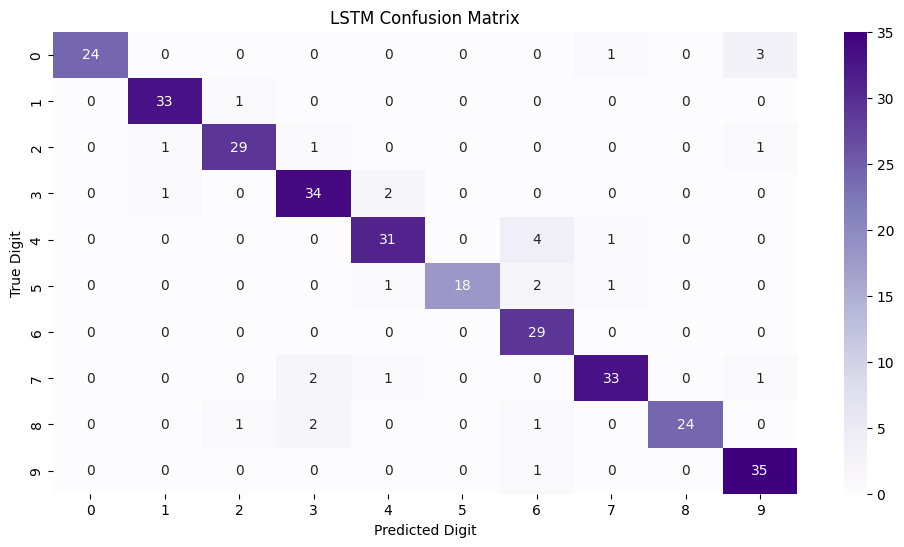

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')

In [32]:
import numpy as np
import os
import IPython.display as ipd

def predict_digit_lstm(file_path):
    # 1. Check if file exists
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return

    # 2. Extract features using the SEQUENCE function (Keep time dimension)
    # Note: We use the function we defined earlier: extract_features_sequence()
    features = extract_features_sequence(file_path)

    if features is not None:
        # 3. Reshape for LSTM: (1 Sample, 44 Time Steps, 13 Features)
        # We add the '1' at the start to tell Keras this is a "batch of 1 file"
        features_input = features.reshape(1, 44, 13)
        
        # 4. Predict
        # prediction_probs will be a list of 10 probabilities, e.g., [0.1, 0.05, 0.8, ...]
        prediction_probs = model.predict(features_input, verbose=0)
        
        # 5. Get the highest probability (The winner)
        predicted_digit = np.argmax(prediction_probs)
        confidence = np.max(prediction_probs)
        
        # 6. Output
        print(f"\n---------------------------------------")
        print(f"File: {os.path.basename(file_path)}")
        print(f"Prediction: {predicted_digit}")
        print(f"Confidence: {confidence*100:.2f}%")
        print(f"---------------------------------------")
        
        # Play the audio
        ipd.display(ipd.Audio(file_path))
        
    else:
        print("Error processing audio.")

# --- EXAMPLE USAGE ---
# Test on a specific file (Change the name/digit to test others)
test_file = os.path.join(DATASET_PATH, 'Mohammed ESSALHI', '0', 'R-09.wav') 

predict_digit_lstm(test_file)


---------------------------------------
File: R-09.wav
Prediction: 0
Confidence: 99.90%
---------------------------------------
